# Development 2: download one block and inspect it

Goal: read the REAL camera and LiDAR names, the calibration layout and the
scene context fields, and confirm the dataset toolkit behaves as documented.
No model, no metrics, no GPU needed.

Run top to bottom. Cell 6 is the long one (a few GB download). Everything
before it is quick. Reports are saved to Drive under `inspection/`.

In [1]:
# --- 1. Configuration ---
PERSIST_MODE = "drive"
SPLIT = "val"                     # develop the pipeline on val, keep test untouched until the protocol is frozen
BLOCK = 11                        # smallest full 20-scene val block: about 4.9 GB with camera + base
LAYERS = ["camera_keyframes"]     # base_keyframes is always added. List EVERY layer wanted, every time

In [ ]:
# === CODE SYNC (auto-generated by `python -m vggt_aura.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m vggt_aura.sync   and reopen this notebook.")

In [3]:
# --- 3. Start the session: Drive, installs, token, manifest ---
from vggt_aura.session import start_session

session = start_session(persist_mode=PERSIST_MODE)

Mounted at /content/drive
installing vggt_omega
installing pybind11
installing fzi_aura
persist root: /content/drive/MyDrive/vggt-omega-aura-benchmark
data root   : /content/data/fzi-aura (runtime disk, wiped at session end)


In [4]:
# --- 4. Which blocks can be downloaded right now, and how big are they? ---
import pandas as pd
from vggt_aura import aura_data as ad, pins

pd.set_option("display.width", 200)
chunks, scene_blocks, hub_files = ad.fetch_release_tables(session.data_root / "_release_tables")
blocks = ad.available_blocks(chunks, scene_blocks, hub_files, LAYERS)
print("dataset revision:", pins.AURA_DATASET_REVISION)
print("downloadable blocks for", LAYERS, "->", len(blocks), "| scenes:", int(blocks["n_scenes"].sum()))
print(blocks.loc[["val", "test"]].to_string())

assert (SPLIT, BLOCK) in blocks.index, f"block {(SPLIT, BLOCK)} is not downloadable for {LAYERS}"
SCENE_IDS = ad.block_scene_ids(scene_blocks, SPLIT, BLOCK)
print()
print("chosen:", SPLIT, "block", BLOCK, "->", len(SCENE_IDS), "scenes,", blocks.loc[(SPLIT, BLOCK), "total_gb"], "GB")
print(SCENE_IDS)

dataset revision: 3404bd6b8fcd6eed53a0ec7610650a6393aabb49
downloadable blocks for ['camera_keyframes'] -> 56 | scenes: 1081
layer              n_scenes  base_keyframes  camera_keyframes  total_gb
split scene_block                                                      
val   0                  20            3.10              4.13      7.23
      1                  20            2.96              4.93      7.89
      2                  20            2.14              4.27      6.41
      10                 20            1.14              3.79      4.93
      11                 20            1.44              3.47      4.91
      12                  7            0.23              1.31      1.54
test  0                  20            3.00              4.25      7.25
      1                  20            2.61              4.19      6.80
      2                  20            1.60              3.23      4.83
      3                  20            1.57              3.28      4.85
      11   

In [5]:
# --- 5. Dry run: what the downloader itself says it will fetch ---
ad.download_block(session.data_root, SPLIT, BLOCK, SCENE_IDS, LAYERS, dry_run=True)

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes --jobs 8 --verify --dry-run


0

In [6]:
# --- 6. Download and extract (the long step). Skipped if the block is already on this runtime ---
import shutil, time

if ad.block_on_disk(session.data_root, SCENE_IDS, LAYERS):
    print("block already on disk, skipping download")
else:
    started = time.time()
    ad.download_block(session.data_root, SPLIT, BLOCK, SCENE_IDS, LAYERS)
    print(f"download and extract took {(time.time() - started) / 60:.1f} min")
free = shutil.disk_usage("/content").free / 1e9
print(f"free disk now: {free:.0f} GB")

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes --jobs 8 --verify
download and extract took 1.4 min
free disk now: 197 GB


In [7]:
# --- 7. Open the dataset and confirm the toolkit calls from the dataset card ---
from fzi_aura import FZIAURADataset

dataset = FZIAURADataset(session.data_root, split=SPLIT)
print("scenes in split on disk:", len(dataset), "| layers:", sorted(dataset.available_layers or []))
scene = dataset[0]
print("first scene:", scene.scene_id, "| samples:", len(scene), "| duration s:", scene.duration_s)
print("cameras on disk :", scene.available_cameras())
print("lidars on disk  :", scene.available_lidars(), "(empty is expected: no LiDAR layer downloaded yet)")


def check(label, fn):
    try:
        print(f"  OK    {label}: {fn()}")
    except Exception as err:
        print(f"  FAIL  {label}: {type(err).__name__}: {str(err)[:160]}")


CAMERA = scene.available_cameras()[0]
box_frames = scene.frames(sample_filter="boxes_3d", require_cameras=[CAMERA])
print("API checks, using camera", repr(CAMERA))
check("scene.frames(sample_filter='boxes_3d', require_cameras=[...])", lambda: f"{len(box_frames)} frames")
frame = box_frames[0]
check("frame.load_camera", lambda: f"shape {frame.load_camera(CAMERA).shape}, dtype {frame.load_camera(CAMERA).dtype}")
check("frame.load_boxes(frame='base_link')", lambda: f"{len(frame.load_boxes(frame='base_link'))} boxes")
check("frame.load_ego_pose", lambda: f"4x4, position {frame.load_ego_pose()[:3, 3].round(2).tolist()}")
check("'front_medium' is a camera here", lambda: "front_medium" in scene.available_cameras())
check("first box fields", lambda: next(iter(frame.load_boxes(frame="base_link"))))

scenes in split on disk: 20 | layers: ['base_keyframes', 'camera_keyframes']
first scene: 2025-07-15-13-11-47|24 | samples: 200 | duration s: 19.949999872
cameras on disk : ('front_medium', 'front_tele', 'front_wide', 'left_forward', 'left_rearward', 'rear_wide', 'right_forward', 'right_rearward')
lidars on disk  : () (empty is expected: no LiDAR layer downloaded yet)
API checks, using camera 'front_medium'
  OK    scene.frames(sample_filter='boxes_3d', require_cameras=[...]): 40 frames
  OK    frame.load_camera: shape (1200, 1920, 3), dtype uint8
  OK    frame.load_boxes(frame='base_link'): 28 boxes
  OK    frame.load_ego_pose: 4x4, position [-608.74, 598.41, -27.53]
  OK    'front_medium' is a camera here: True
  OK    first box fields: Box3D(center=array([ 18.31820548, -11.3231042 ,   0.8399934 ]), size_lwh=array([4.25214158, 1.81496734, 1.62764157]), rotation_xyzw=array([ 0.0104627 , -0.0104856 ,  0.71135477,  0.70267701]), category='car', object_id='car:5', timestamp_ns=1752585602

In [8]:
# --- 8. One row of facts per scene, saved to Drive ---
rows = []
for index in range(len(dataset)):
    rows.append(ad.scene_summary(dataset[index]))
summary = pd.DataFrame(rows)

tag = f"{SPLIT}_block{BLOCK:06d}"
report_dir = session.persist_root / "inspection"
ad.save_json(report_dir / f"{tag}_scenes.json", rows)

show = ["scene_id", "keyframes", "keyframe_gap_s_median", "keyframe_spacing_m_median", "speed_kph_median",
        "road_type", "weather", "start_hour_utc", "boxes_total", "keyframes_with_zero_boxes"]
print(summary[show].round(2).to_string())
print()
print("signal columns (first scene):", summary.loc[0, "signal_columns"])
print("context columns missing anywhere:", sorted({c for row in rows for c in row["context_columns_missing"]}))

                   scene_id  keyframes  keyframe_gap_s_median  keyframe_spacing_m_median  speed_kph_median road_type           weather  start_hour_utc  boxes_total  keyframes_with_zero_boxes
0    2025-07-15-13-11-47|24         40                    0.5                       1.33              9.28     urban        light rain              13         1793                          0
1    2025-06-11-13-47-25|25         40                    0.5                       0.60              3.97     urban         clear sky              13         1720                          0
2    2025-06-13-07-09-37|78         40                    0.5                       4.28             30.55     urban  scattered clouds               7         1608                          0
3    2025-07-15-14-15-47|71         40                    0.5                       3.09             22.52     urban   overcast clouds              14         1587                          0
4    2025-07-15-13-11-47|63         40       

In [9]:
# --- 9. Sensor names: are they the same in every scene of the block? ---
for column in ("cameras_on_disk", "cameras_calibrated", "lidars_calibrated", "radars_calibrated"):
    variants = summary[column].map(tuple).value_counts()
    print(f"{column}: {len(variants)} variant(s)")
    for names, count in variants.items():
        print(f"   {count:2d} scenes -> {list(names)}")

cameras_on_disk: 1 variant(s)
   20 scenes -> ['front_medium', 'front_tele', 'front_wide', 'left_forward', 'left_rearward', 'rear_wide', 'right_forward', 'right_rearward']
cameras_calibrated: 1 variant(s)
   20 scenes -> ['front_medium', 'front_tele', 'front_wide', 'left_forward', 'left_rearward', 'rear_wide', 'right_forward', 'right_rearward']
lidars_calibrated: 1 variant(s)
   20 scenes -> ['front_left', 'front_right', 'rear_left', 'rear_right', 'top_left', 'top_right']
radars_calibrated: 1 variant(s)
   20 scenes -> ['front_left', 'front_right', 'rear_center']


In [10]:
# --- 10. Calibration layout, per camera. Trap 4: is P for the native image size? ---
import hashlib, json

report = ad.calibration_report(scene)
ad.save_json(report_dir / f"{tag}_calibration_first_scene.json", report)
print("calibration.json top-level keys:", report["top_level_keys"])
print("sensor keys:", report["sensor_keys"])
print()
print(pd.DataFrame(report["cameras"]).T[["image_width_height", "fx_fy_cx_cy", "cx_cy_over_width_height",
      "P_fourth_column", "position_in_base_link_m", "optical_axis_in_base_link", "image_minus_sample_ms"]].to_string())
print()
first_camera = scene.calibration().sensor_ids("camera")[0]
print("RAW entry for camera", repr(first_camera))
print(json.dumps(scene.calibration().sensor(f"camera/{first_camera}"), indent=1)[:2500])

hashes = {dataset[i].scene_id: hashlib.sha256((dataset[i].path / "calibration.json").read_bytes()).hexdigest()[:10]
          for i in range(len(dataset))}
print()
print("distinct calibration files in this block:", len(set(hashes.values())), "of", len(hashes), "scenes")

calibration.json top-level keys: ['calibration_id', 'coordinate_system', 'format_version', 'sensors']
sensor keys: ['camera/front_medium', 'camera/front_tele', 'camera/front_wide', 'camera/left_forward', 'camera/left_rearward', 'camera/rear_wide', 'camera/right_forward', 'camera/right_rearward', 'lidar/front_left', 'lidar/front_right', 'lidar/rear_left', 'lidar/rear_right', 'lidar/top_left', 'lidar/top_right', 'radar/front_left', 'radar/front_right', 'radar/rear_center']

               image_width_height                                     fx_fy_cx_cy cx_cy_over_width_height  P_fourth_column position_in_base_link_m optical_axis_in_base_link image_minus_sample_ms
front_medium         [1920, 1200]  [1614.61267, 1694.19946, 975.26354, 589.81466]          [0.508, 0.492]  [0.0, 0.0, 0.0]    [1.677, 0.19, 1.485]       [1.0, -0.024, 0.01]                 0.004
front_tele           [1920, 1200]   [3426.38794, 3449.35669, 953.15189, 587.3954]          [0.496, 0.489]  [0.0, 0.0, 0.0]  [1.669, -

In [11]:
# --- 11. Strata counts. Trap 7: count before promising a stratified result ---
print("scenes per road_type x weather:")
print(pd.crosstab(summary["road_type"], summary["weather"]).to_string())
print()
print("keyframe spacing in metres by road_type (trap 6):")
print(summary.groupby("road_type")["keyframe_spacing_m_median"].describe()[["count", "min", "50%", "max"]].round(1).to_string())
print()
print("scenes whose road_type changes mid-scene:", int((summary["road_type_values"].map(len) > 1).sum()))
print("start hour (UTC) counts:", summary["start_hour_utc"].value_counts().sort_index().to_dict())

scenes per road_type x weather:
weather    broken clouds  clear sky  few clouds  light rain  overcast clouds  scattered clouds
road_type                                                                                     
overland               0          1           1           0                0                 0
urban                  1          4           0           3                6                 4

keyframe spacing in metres by road_type (trap 6):
           count  min   50%   max
road_type                        
overland     2.0  9.3  10.0  10.7
urban       18.0  0.1   2.2   4.3

scenes whose road_type changes mid-scene: 2
start hour (UTC) counts: {7: 2, 8: 1, 12: 1, 13: 13, 14: 3}


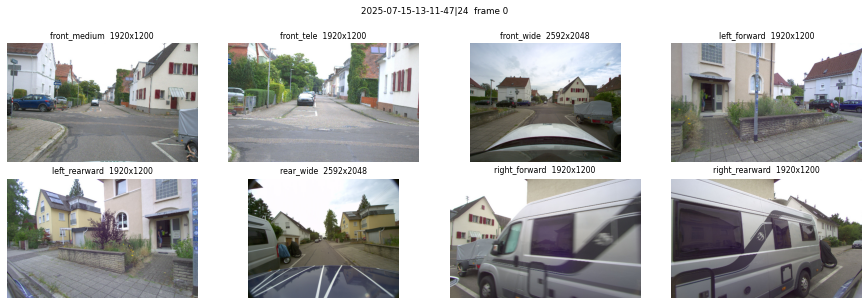

In [12]:
# --- 12. Look at the images: one keyframe, every camera ---
import matplotlib.pyplot as plt

cameras = list(scene.available_cameras())
columns = 4
rows_n = -(-len(cameras) // columns)
figure, axes = plt.subplots(rows_n, columns, figsize=(3.2 * columns, 2.2 * rows_n), dpi=70)
for axis in axes.ravel():
    axis.axis("off")
for axis, camera_id in zip(axes.ravel(), cameras):
    image = frame.load_camera(camera_id)
    axis.imshow(image[::4, ::4])          # downsample so the notebook file stays small
    axis.set_title(f"{camera_id}  {image.shape[1]}x{image.shape[0]}", fontsize=8)
figure.suptitle(f"{scene.scene_id}  frame {frame.frame_index}", fontsize=9)
figure.tight_layout()
figure.savefig(report_dir / f"{tag}_cameras.png", dpi=70)
plt.show()

In [13]:
# --- 13. Raw files, truncated: scene.json, one sample row, semantic classes ---
def dump(title, value, limit=1800):
    text = json.dumps(value, indent=1, default=str)
    print(f"===== {title} ({len(text)} chars) =====")
    print(text[:limit] + (" ...[truncated]" if len(text) > limit else ""))
    print()


dump("scene.json", scene.load_metadata())
dump("one keyframe row of samples.jsonl", frame.sample_dict)
classes_path = scene.path / "labels" / "semantic" / "classes.json"
if classes_path.is_file():
    dump("labels/semantic/classes.json", json.loads(classes_path.read_text(encoding="utf-8")), limit=3000)
else:
    print("classes.json not found at", classes_path)

===== scene.json (1747 chars) =====
{
 "counts": {
  "boxes_3d_aeva_rows": 0,
  "boxes_3d_annotated_keyframes": 40,
  "boxes_3d_empty_keyframes": 0,
  "boxes_3d_nonempty_keyframes": 40,
  "boxes_3d_rows": 1793,
  "camera_frames": 1600,
  "lidar_frames": {
   "motion_compensated": 1200,
   "raw": 1200
  },
  "poses": 200,
  "radar_frames": 1197,
  "radar_sensors": 3,
  "samples": 200,
  "semantic_lidar_frames": 240,
  "semantic_lidar_sensors": 6,
  "sensor_frame_label_files": 6,
  "vehicle_signal_samples": 401
 },
 "debug_exports": {
  "include_fused_motion_compensated": false,
  "note": null
 },
 "duration_s": 19.949999872,
 "end_timestamp_ns": 1752585622100000000,
 "format_version": "v1.2.1",
 "modalities": [
  "lidar_raw",
  "lidar_motion_compensated",
  "camera",
  "ego",
  "poses",
  "radar",
  "labels_3d",
  "labels_semantic_lidar"
 ],
 "name": "2025-07-15-13-11-47_24",
 "paths": {
  "box_sources": "labels/box_sources.json",
  "boxes_3d": "labels/boxes_3d.jsonl",
  "boxes_3d_aeva_

In [14]:
# --- 14. Record what was inspected, so the next session knows ---
for scene_id in summary["scene_id"]:
    if not session.manifest.is_done(scene_id, "inspect"):
        session.manifest.mark_done(scene_id, "inspect", split=SPLIT, block=BLOCK,
                                   dataset_revision=pins.AURA_DATASET_REVISION)
print("inspected scenes recorded:", len(session.manifest.done("inspect")))
print("reports saved in:", report_dir)

inspected scenes recorded: 20
reports saved in: /content/drive/MyDrive/vggt-omega-aura-benchmark/inspection
